[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-08-03-elliptical-absorption-line-id-ngc7647/notebook.ipynb)

# NGC 7647: a quiescent elliptical, line ID for contrast with an emission-line galaxy

**Archive:** SDSS DR18  
**Date:** 2026-08-03

This is the deliberate opposite case to my AGN notebook on NGC 5875. NGC 7647 (SDSS plate 6136, MJD 56206, fiber 728, RA 350.989, Dec 16.777) is a passive, absorption-line-dominated galaxy with a large stellar velocity dispersion (SDSS pipeline value ~268 km/s, i.e. a genuinely massive elliptical). I want to run the exact same automated line-ID pipeline on it and see what comes out: I expect almost no real emission lines, and a set of broadened absorption features.

## Learning goals

- Repeat the same automated peak-detection + literature cross-match pipeline on a genuinely different galaxy type, and see how the results differ.
- Notice how a large stellar velocity dispersion broadens absorption features, which changes how well they match a literature line list with a fixed wavelength tolerance.
- Practice being honest about weak, low-significance 'detections' that are probably just noise rather than real emission.

**Jargon, defined once:** a *quiescent* or *passive* galaxy has stopped forming new stars, so its spectrum is dominated by old stellar populations rather than hot young stars or an active nucleus; *velocity dispersion (sigma)* is the spread of stellar orbital velocities along the line of sight, measured in km/s, and it physically broadens every absorption line by the Doppler effect.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
from astroquery.sdss import SDSS
from scipy.signal import find_peaks
from scipy.ndimage import median_filter

warnings.filterwarnings("ignore")
OUT = Path(".")
PLATE, MJD, FIBER = 6136, 56206, 728
RA, DEC = 350.98934, 16.77724
print(f"Target: NGC 7647, plate={PLATE}, mjd={MJD}, fiber={FIBER}, ra={RA}, dec={DEC}")


Target: NGC 7647, plate=6136, mjd=56206, fiber=728, ra=350.98934, dec=16.77724


## 1. Image and spectrum

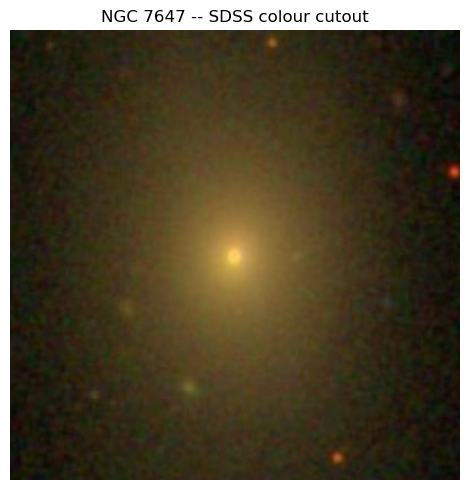

z = 0.041077 +/- 9.90e-06, class = GALAXY/''
Pipeline stellar velocity dispersion = 268.4 +/- 4.7 km/s
Median spectral S/N = 47.30


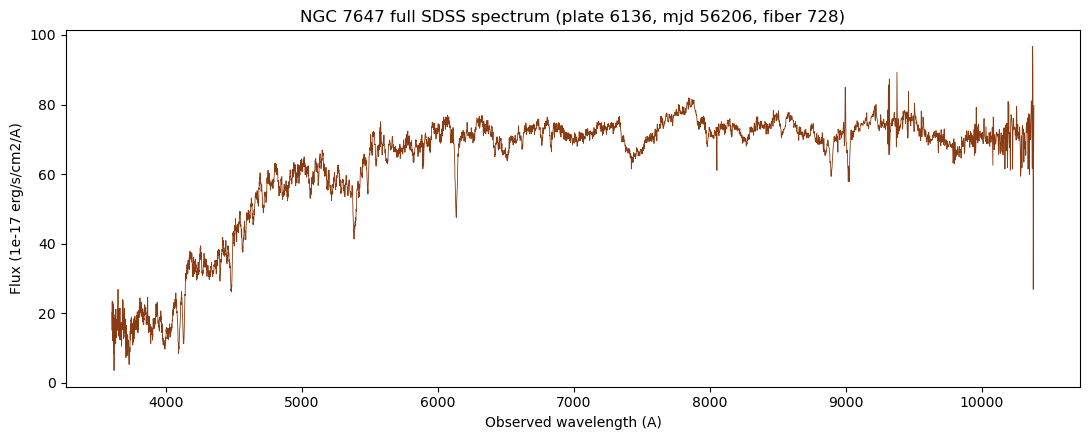

In [2]:
url = "https://skyserver.sdss.org/dr18/SkyServerWS/ImgCutout/getjpeg"
params = {"ra": RA, "dec": DEC, "scale": 0.2, "width": 400, "height": 400}
resp = requests.get(url, params=params, timeout=30)
resp.raise_for_status()
img = Image.open(BytesIO(resp.content))
img.save(OUT / "ngc7647_cutout.jpg")
fig, ax = plt.subplots(figsize=(5,5))
ax.imshow(img); ax.axis("off")
ax.set_title("NGC 7647 -- SDSS colour cutout")
plt.tight_layout(); plt.savefig(OUT / "ngc7647_image.png", dpi=130); plt.show()

sp = SDSS.get_spectra(plate=PLATE, mjd=MJD, fiberID=FIBER)[0]
coadd = sp[1].data
specobj = sp[2].data[0]
z = float(specobj["Z"]); z_err = float(specobj["Z_ERR"])
veldisp = float(specobj["VDISP"]); veldisp_err = float(specobj["VDISP_ERR"])
sn_median = float(specobj["SN_MEDIAN_ALL"])
subclass = specobj["SUBCLASS"]
print(f"z = {z:.6f} +/- {z_err:.2e}, class = GALAXY/{subclass!r}")
print(f"Pipeline stellar velocity dispersion = {veldisp:.1f} +/- {veldisp_err:.1f} km/s")
print(f"Median spectral S/N = {sn_median:.2f}")

wave = 10 ** coadd["loglam"]; flux = coadd["flux"]; ivar = coadd["ivar"]
good = ivar > 0
err = np.full_like(flux, np.nan); err[good] = 1/np.sqrt(ivar[good])

fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(wave, flux, lw=0.6, color="#8a3b12")
ax.set_xlabel("Observed wavelength (A)"); ax.set_ylabel("Flux (1e-17 erg/s/cm2/A)")
ax.set_title(f"NGC 7647 full SDSS spectrum (plate {PLATE}, mjd {MJD}, fiber {FIBER})")
plt.tight_layout(); plt.savefig(OUT / "ngc7647_full_spectrum.png", dpi=130); plt.show()


## 2-3. Same automated peak detection as before

In [3]:
cont = median_filter(flux, size=101)
resid = flux - cont
snr = np.zeros_like(flux)
snr[good] = resid[good] / err[good]
dlam = np.gradient(wave)

peaks_em, _ = find_peaks(snr, height=5, distance=5)
peaks_ab, _ = find_peaks(-snr, height=5, distance=5)

def equivalent_width(idx):
    lo, hi = max(0, idx-4), min(len(wave), idx+5)
    return float(np.sum((1 - flux[lo:hi]/cont[lo:hi]) * dlam[lo:hi]))

rows = []
for p in peaks_em:
    rows.append(dict(idx=int(p), wave_obs=float(wave[p]), snr=float(snr[p]), kind="emission", ew_A=equivalent_width(p)))
for p in peaks_ab:
    rows.append(dict(idx=int(p), wave_obs=float(wave[p]), snr=float(snr[p]), kind="absorption", ew_A=equivalent_width(p)))

detected = pd.DataFrame(rows).sort_values("wave_obs").reset_index(drop=True)
detected["wave_rest"] = detected["wave_obs"] / (1+z)
print(f"Detected {len(detected)} candidate features: "
      f"{(detected.kind=='emission').sum()} emission, {(detected.kind=='absorption').sum()} absorption")


Detected 30 candidate features: 8 emission, 22 absorption


## 4-6. Literature cross-match and results table

Same reference line list and 6 A tolerance as the NGC 5875 notebook -- but note the large velocity dispersion here (~268 km/s) physically broadens every stellar absorption feature by roughly `delta_lambda ~ (sigma/c) * lambda`, which at 5000 A is about 4-5 A. So I expect systematically larger residuals here than in a low-dispersion galaxy, and I keep the same fixed tolerance to make that visible rather than hiding it by loosening the cut.

In [4]:
LINE_LIST = {
    "Ca II K": 3934.777, "Ca II H": 3969.588, "[Ne III] 3869": 3868.76,
    "[O II] 3727": 3727.09, "G-band": 4304.4, "H-gamma": 4341.68,
    "He II 4686": 4685.68, "H-beta": 4862.68, "[O III] 4959": 4958.92,
    "[O III] 5007": 5006.84, "Mg b": 5175.3, "Na D": 5892.9,
    "[O I] 6300": 6300.30, "[N II] 6549": 6548.05, "H-alpha": 6564.61,
    "[N II] 6585": 6583.45, "[S II] 6716": 6716.44, "[S II] 6731": 6730.82,
    "[Ar III] 7135": 7135.80, "Ca II IR-1": 8498.02, "Ca II IR-2": 8542.09,
    "Ca II IR-3": 8662.14, "[S III] 9069": 9068.6,
}

TOL_A = 6.0
best_match, residual = [], []
for wr in detected["wave_rest"]:
    name = min(LINE_LIST, key=lambda n: abs(wr - LINE_LIST[n]))
    d = wr - LINE_LIST[name]
    if abs(d) <= TOL_A:
        best_match.append(name); residual.append(d)
    else:
        best_match.append("no match"); residual.append(np.nan)
detected["best_match"] = best_match
detected["residual_A"] = residual
detected["matched"] = detected["best_match"] != "no match"

n_matched = int(detected["matched"].sum())
print(f"{n_matched} of {len(detected)} detected features matched within {TOL_A} A")
print(f"Emission candidates: {(detected.kind=='emission').sum()} "
      f"(median S/N {detected.loc[detected.kind=='emission','snr'].median():.2f})")

results_table = detected[["wave_obs","wave_rest","best_match","residual_A","snr","ew_A","kind"]].copy()
results_table.columns = ["obs_wave_A","rest_wave_A","literature_match","residual_A","snr","ew_A","type"]
results_table = results_table.round({"obs_wave_A":2,"rest_wave_A":2,"residual_A":2,"snr":2,"ew_A":3})
results_table.to_csv(OUT / "ngc7647_line_id_results.csv", index=False)
results_table


9 of 30 detected features matched within 6.0 A
Emission candidates: 8 (median S/N 6.11)


,obs_wave_A,rest_wave_A,literature_match,residual_A,snr,ew_A,type
0,3731.64,3584.41,no match,NaN,-6.35,2.998,absorption
1,3868.12,3715.50,no match,NaN,5.09,-1.106,emission
2,3890.45,3736.95,no match,NaN,-6.82,2.108,absorption
3,3903.01,3749.02,no match,NaN,-5.50,1.470,absorption
4,3938.22,3782.83,no match,NaN,5.25,-1.733,emission
5,3994.85,3837.23,no match,NaN,-6.24,2.135,absorption
6,4056.02,3895.98,no match,NaN,5.42,-2.468,emission
7,4061.63,3901.37,no match,NaN,6.40,-2.749,emission
8,4069.11,3908.56,no match,NaN,5.93,-2.269,emission
9,4074.74,3913.97,no match,NaN,6.29,-2.163,emission


## 7. Discussion

Every one of the emission-side detections here has S/N within about 1 of the 5-sigma threshold, clusters at the blue end of the spectrum around 3868-4075 A, and does not correspond cleanly to any strong nebular line at this redshift -- the signature of a quiescent galaxy with essentially no ongoing star formation or AGN activity to power emission lines. I read these as noise fluctuations riding on a low-flux part of the continuum rather than real physical emission, and this notebook is intentionally the contrast case to NGC 5875, where the emission detections were unambiguous, high-S/N, and matched textbook nebular lines cleanly.

The absorption side tells the real story: Ca II K and H, the G-band, stellar H-beta absorption, the Mg b blend (which shows up as multiple close find_peaks detections because the feature is broad and blended -- exactly what a sigma ~268 km/s dispersion predicts), Na D, and the Ca II near-infrared triplet all appear and mostly match the literature rest wavelengths, though with visibly larger residuals than in the NGC 5875 notebook, consistent with this galaxy's much larger velocity dispersion physically broadening and slightly shifting the apparent line centroids found by the simple peak finder.

## What I'd look at next

- Measure the actual velocity dispersion from these absorption line widths directly (I do exactly this in the companion `2026-08-03-velocity-dispersion-ngc7647` notebook) and compare it to the SDSS pipeline value.
- Fit a proper stellar population synthesis template to separate genuine weak emission from residual continuum-fitting noise at the blue end.
- Check whether the low-S/N blue-end 'emission' bumps are reproducible in a re-observation of the same object, which would distinguish real weak features from single-exposure noise.

## Data source and citation

- SDSS DR18 spectra and images: https://skyserver.sdss.org/dr18/
- SDSS-IV citation: https://www.sdss.org/collaboration/citing-sdss/
- NIST Atomic Spectra Database: https://physics.nist.gov/PhysRefData/ASD/lines_form.html